<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/GRAFICAS17SEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clase 17/09/25

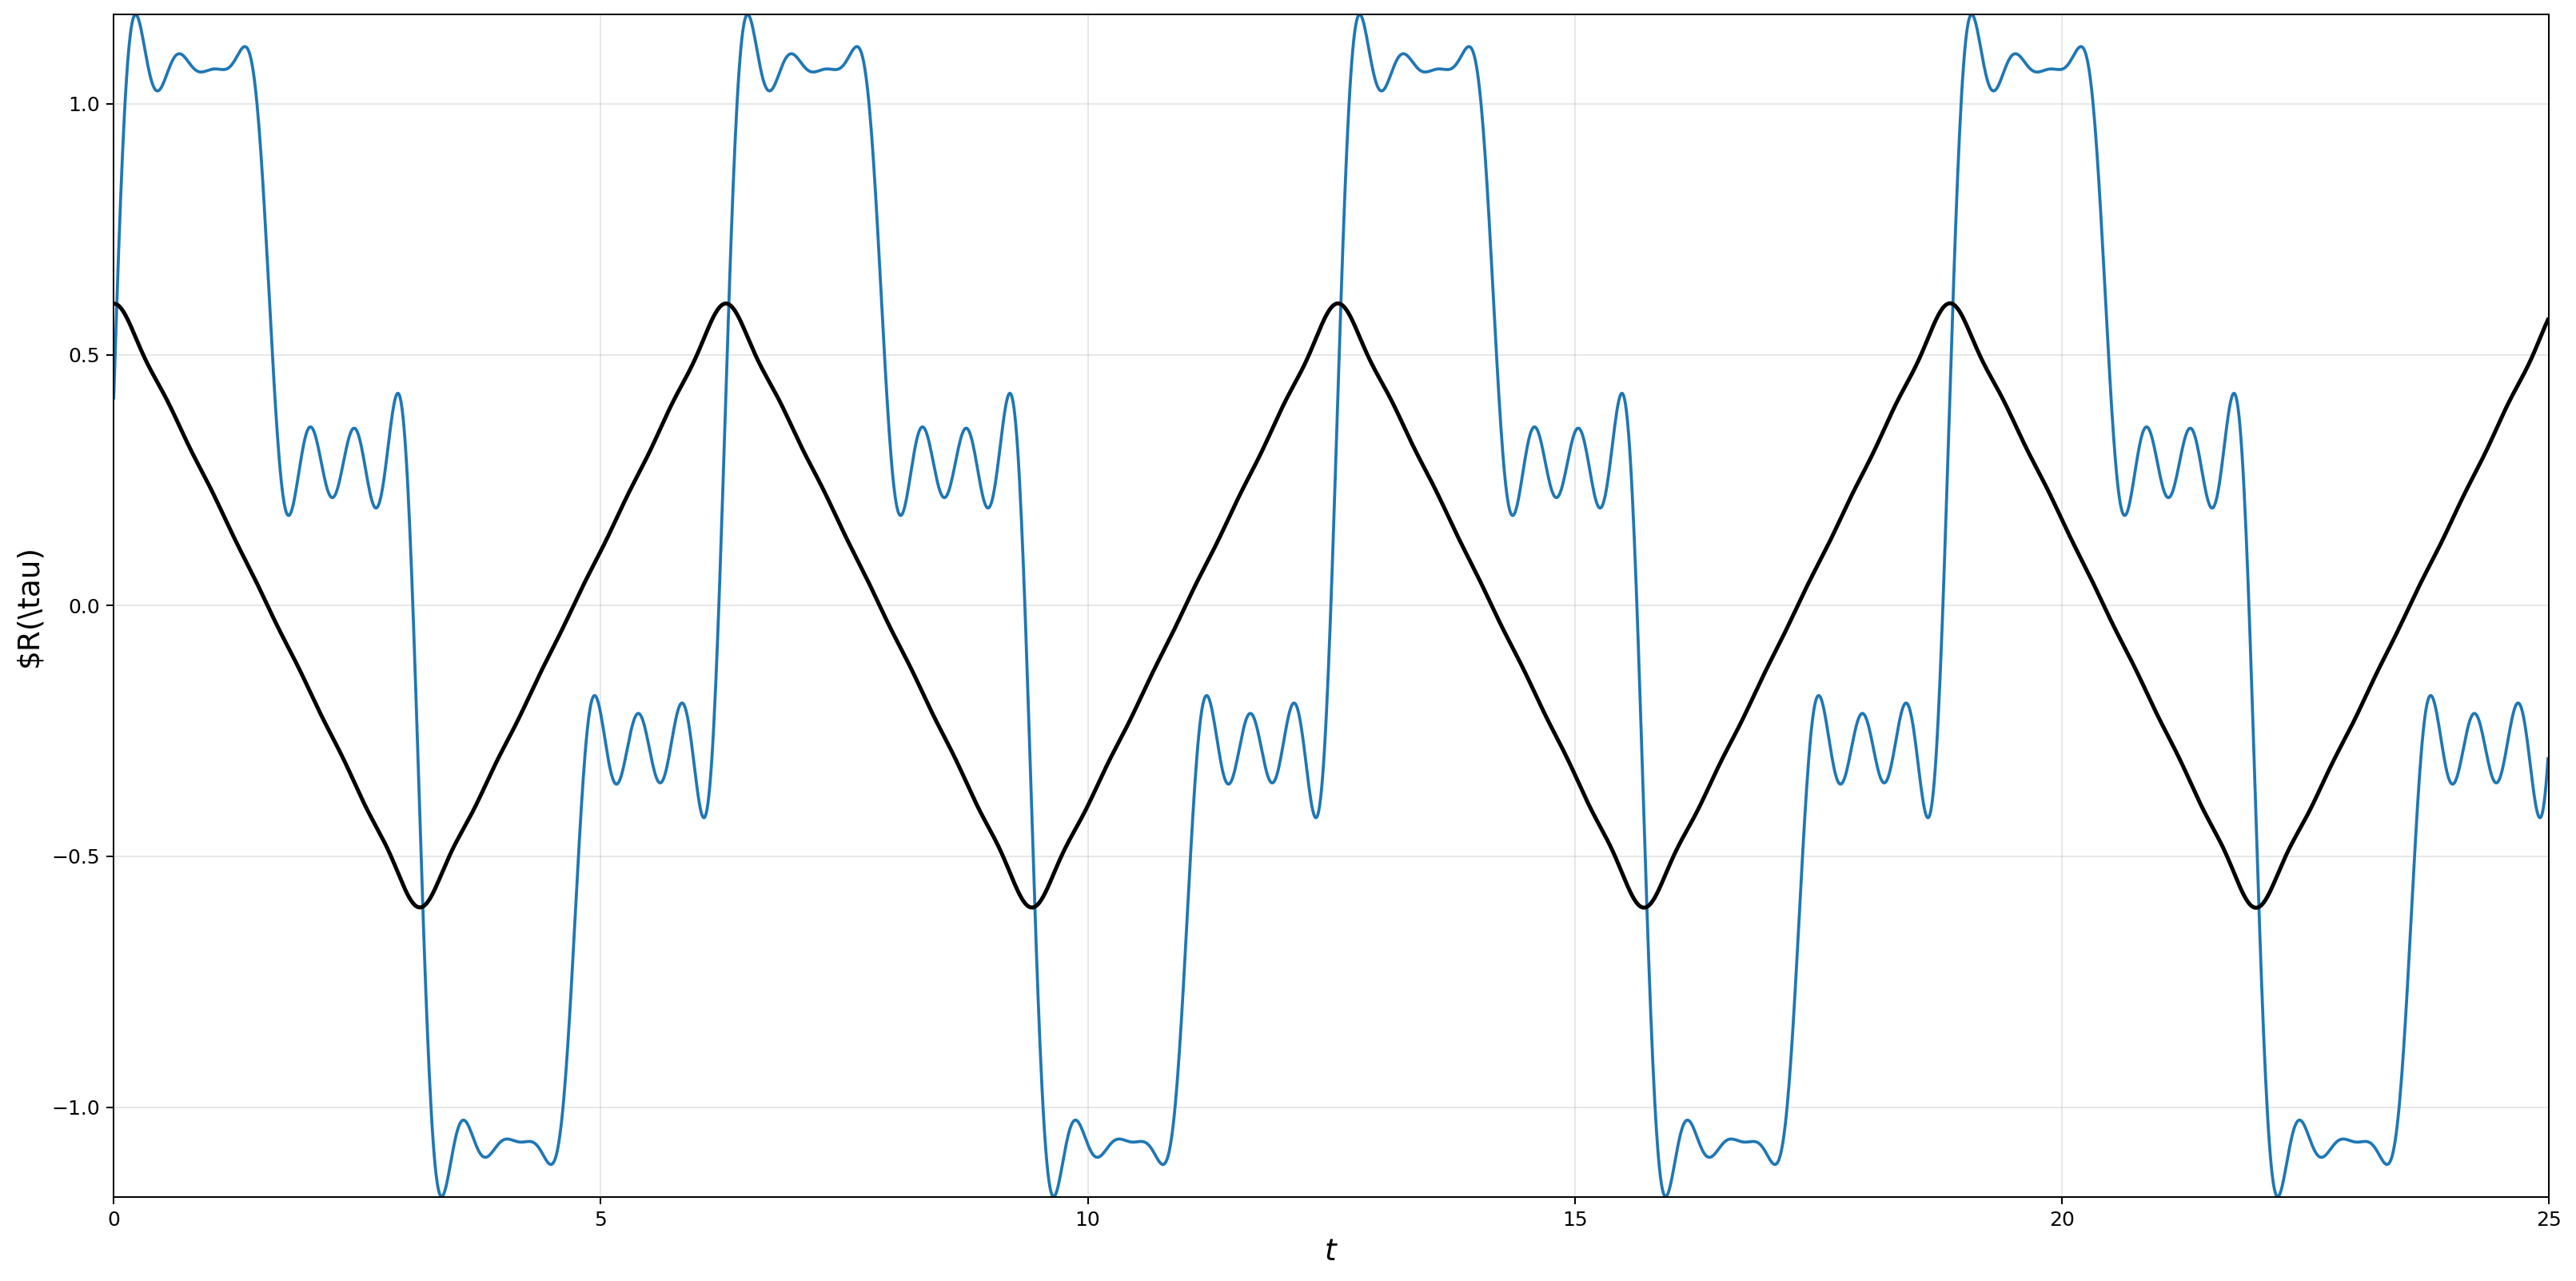

In [20]:
# Correlation function
%matplotlib inline
import numpy as np
import math
import scipy
from scipy import signal
#import scipy.signal

import matplotlib.pyplot as plt  # data plotting
from matplotlib import rcParams
from matplotlib.pyplot import figure

rcParams['figure.figsize']     = [18,9]
rcParams['lines.markersize']   = 9         # marker size in points
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.dpi']     = 180

# Main
#  time stamp
Nsample  = 10000
dt = 1/100  # time step  =>
time = np.arange(Nsample)*dt

# create an 1D array populated with random samples
mu = 0
sigma = 0 # scale
eta = sigma * np.random.randn(Nsample) + mu

# Simulate a Cosine wave
# k0 = 1  # phase shift
# Random phase shift between -1 and 1
k0 = np.random.uniform(-1, 1)

a_k = [1,-3, 5, -7, 9, -11, 13]

# Initialize signal
xi = np.zeros_like(time)

# Add cosine components with scaling by 1/k
for k in a_k:
    xi += np.cos(k * time - k0 * np.pi) / k

# Add noise
xi += eta

# Compute numerically the autocorrelation via Fourier transform
fft_cor = scipy.signal.fftconvolve(xi, xi[::-1])[Nsample-1:]
fft_cor /= (Nsample - np.arange(Nsample))

plt.plot(time[:Nsample//4],xi[:Nsample//4])
plt.xlim(0,time[Nsample//4])
plt.ylim(min(xi[:Nsample//4]),max(xi[:Nsample//4]))
plt.xlabel(r'$t$')
plt.ylabel(r'$x(t)$')
plt.xlabel(r'$t$')
plt.ylabel(r'$R(\tau)');
plt.plot(time[:Nsample//4], fft_cor[:Nsample//4], 'k-', lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Metodos computacionales

In [21]:
def AutoCorr1(X):
    # Compute numerically the autocorrelation via Fourier transform
    Nsample  = len(X) # time length
    fft_cor = scipy.signal.fftconvolve(X, X[::-1],mode='full')[Nsample-1:]
    fft_cor /= (Nsample - np.arange(Nsample))
    return fft_cor[:len(X)//2]

def AutoCorr2(x):
    #  time complexicity is N*log(N)
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

def AutoCorr3(X, twosided=False, tapered=True):
    X = X - X.mean()
    acf = np.correlate(X,X,mode='full')[len(X)-1:]#np.correlate computes also negative lags
    #since the function is symmetric, use only the half with positive lags
    acf = acf / acf[0]# normalize with the variance
    return acf

def AutoCorr4(x):
    xp = x - x.mean()
    min_number_zeros = 2 * len(xp) - 1
    # Zero pad to the next power of two for maximum speed.
    fts = 2 ** np.ceil(np.log2(min_number_zeros)).astype('int')
    ft = np.fft.fft(np.array(xp), fts)
    corr = np.fft.ifft(ft.conjugate() * ft)[:len(xp)].real
    corr /= np.arange(len(xp), 0, -1)
    corr /= corr[0]
    return corr[:len(x)//2]


#Segundo metodo

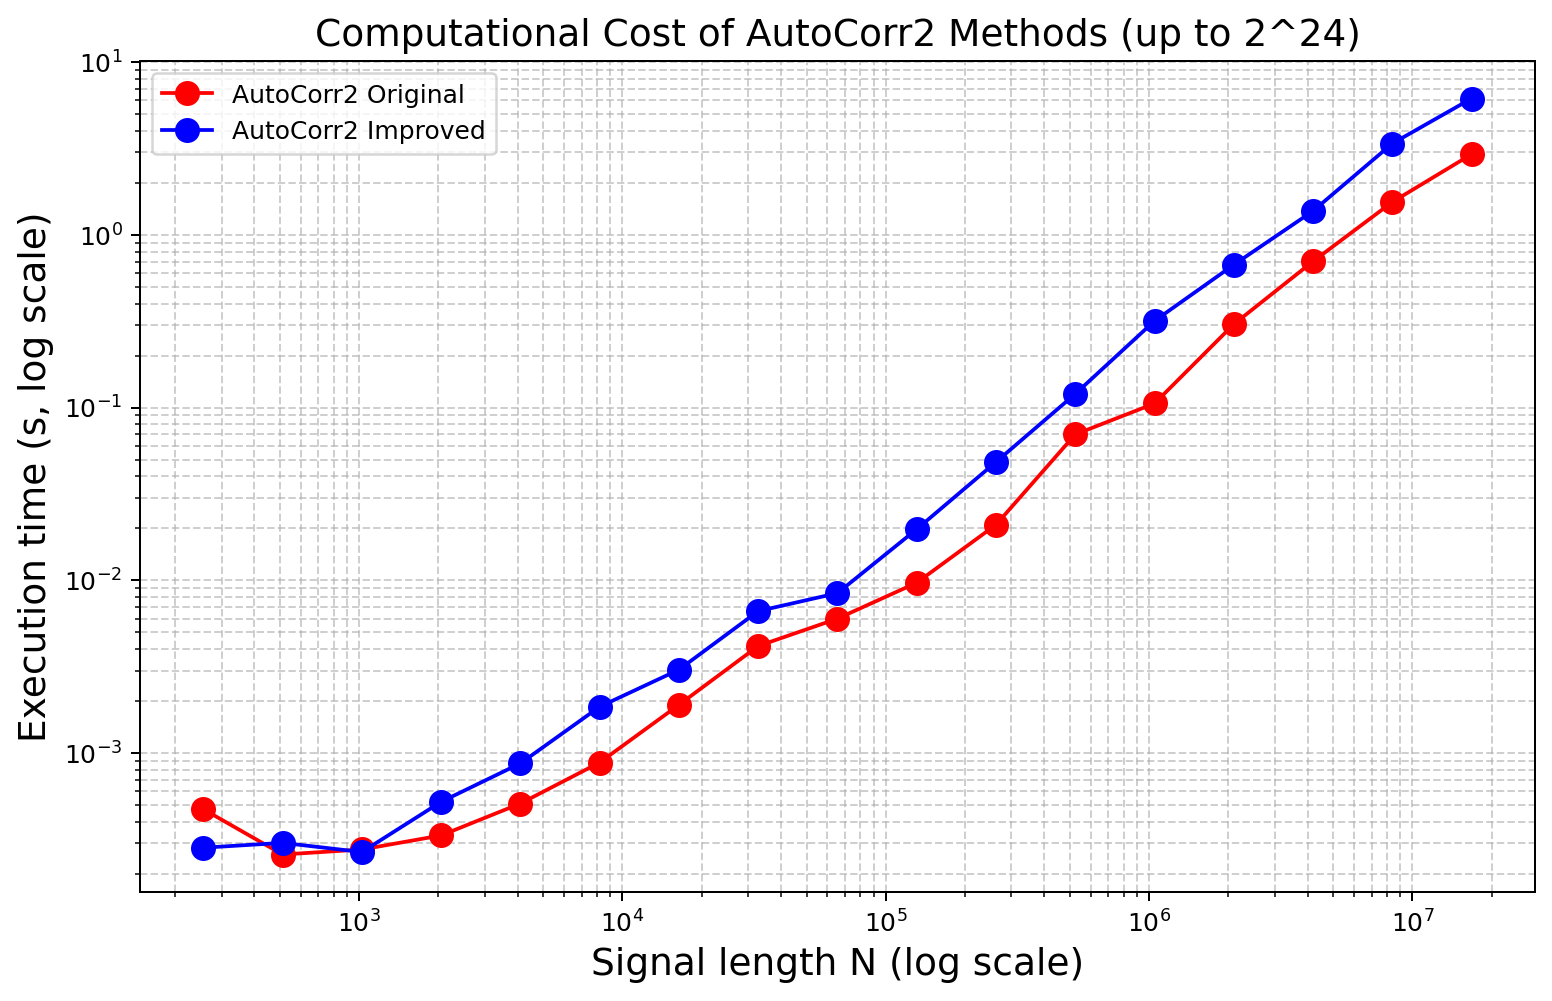

In [23]:
import numpy as np
import time
import matplotlib.pyplot as plt

def AutoCorr2_original(x):
    """Original AutoCorr2 with FFT method"""
    r2 = np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c = (r2/x.shape[0] - np.mean(x)**2) / np.std(x)**2
    return c[:len(x)//2]

def AutoCorr2_improved(x):
    """Improved AutoCorr2 with zero-padding and unbiased normalization"""
    n = len(x)
    nfft = 2**int(np.ceil(np.log2(2*n-1)))
    Xf = np.fft.fft(x - np.mean(x), nfft)
    r2 = np.fft.ifft(np.abs(Xf)**2).real[:n]
    c = r2 / (np.var(x) * np.arange(n, 0, -1))
    return c[:len(x)//2]

# Test sizes up to 2^24
sizes = [2**k for k in range(8, 25)]  # 2^8 ... 2^24
times_original = []
times_improved = []

for N in sizes:
    x = np.random.randn(N)

    # Original timing
    start = time.time()
    AutoCorr2_original(x)
    times_original.append(time.time() - start)

    # Improved timing
    start = time.time()
    AutoCorr2_improved(x)
    times_improved.append(time.time() - start)

# Plot runtime comparison
plt.figure(figsize=(10,6))
plt.loglog(sizes, times_original, 'ro-', label="AutoCorr2 Original")
plt.loglog(sizes, times_improved, 'bo-', label="AutoCorr2 Improved")
plt.xlabel("Signal length N (log scale)")
plt.ylabel("Execution time (s, log scale)")
plt.title("Computational Cost of AutoCorr2 Methods (up to 2^24)")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.show()


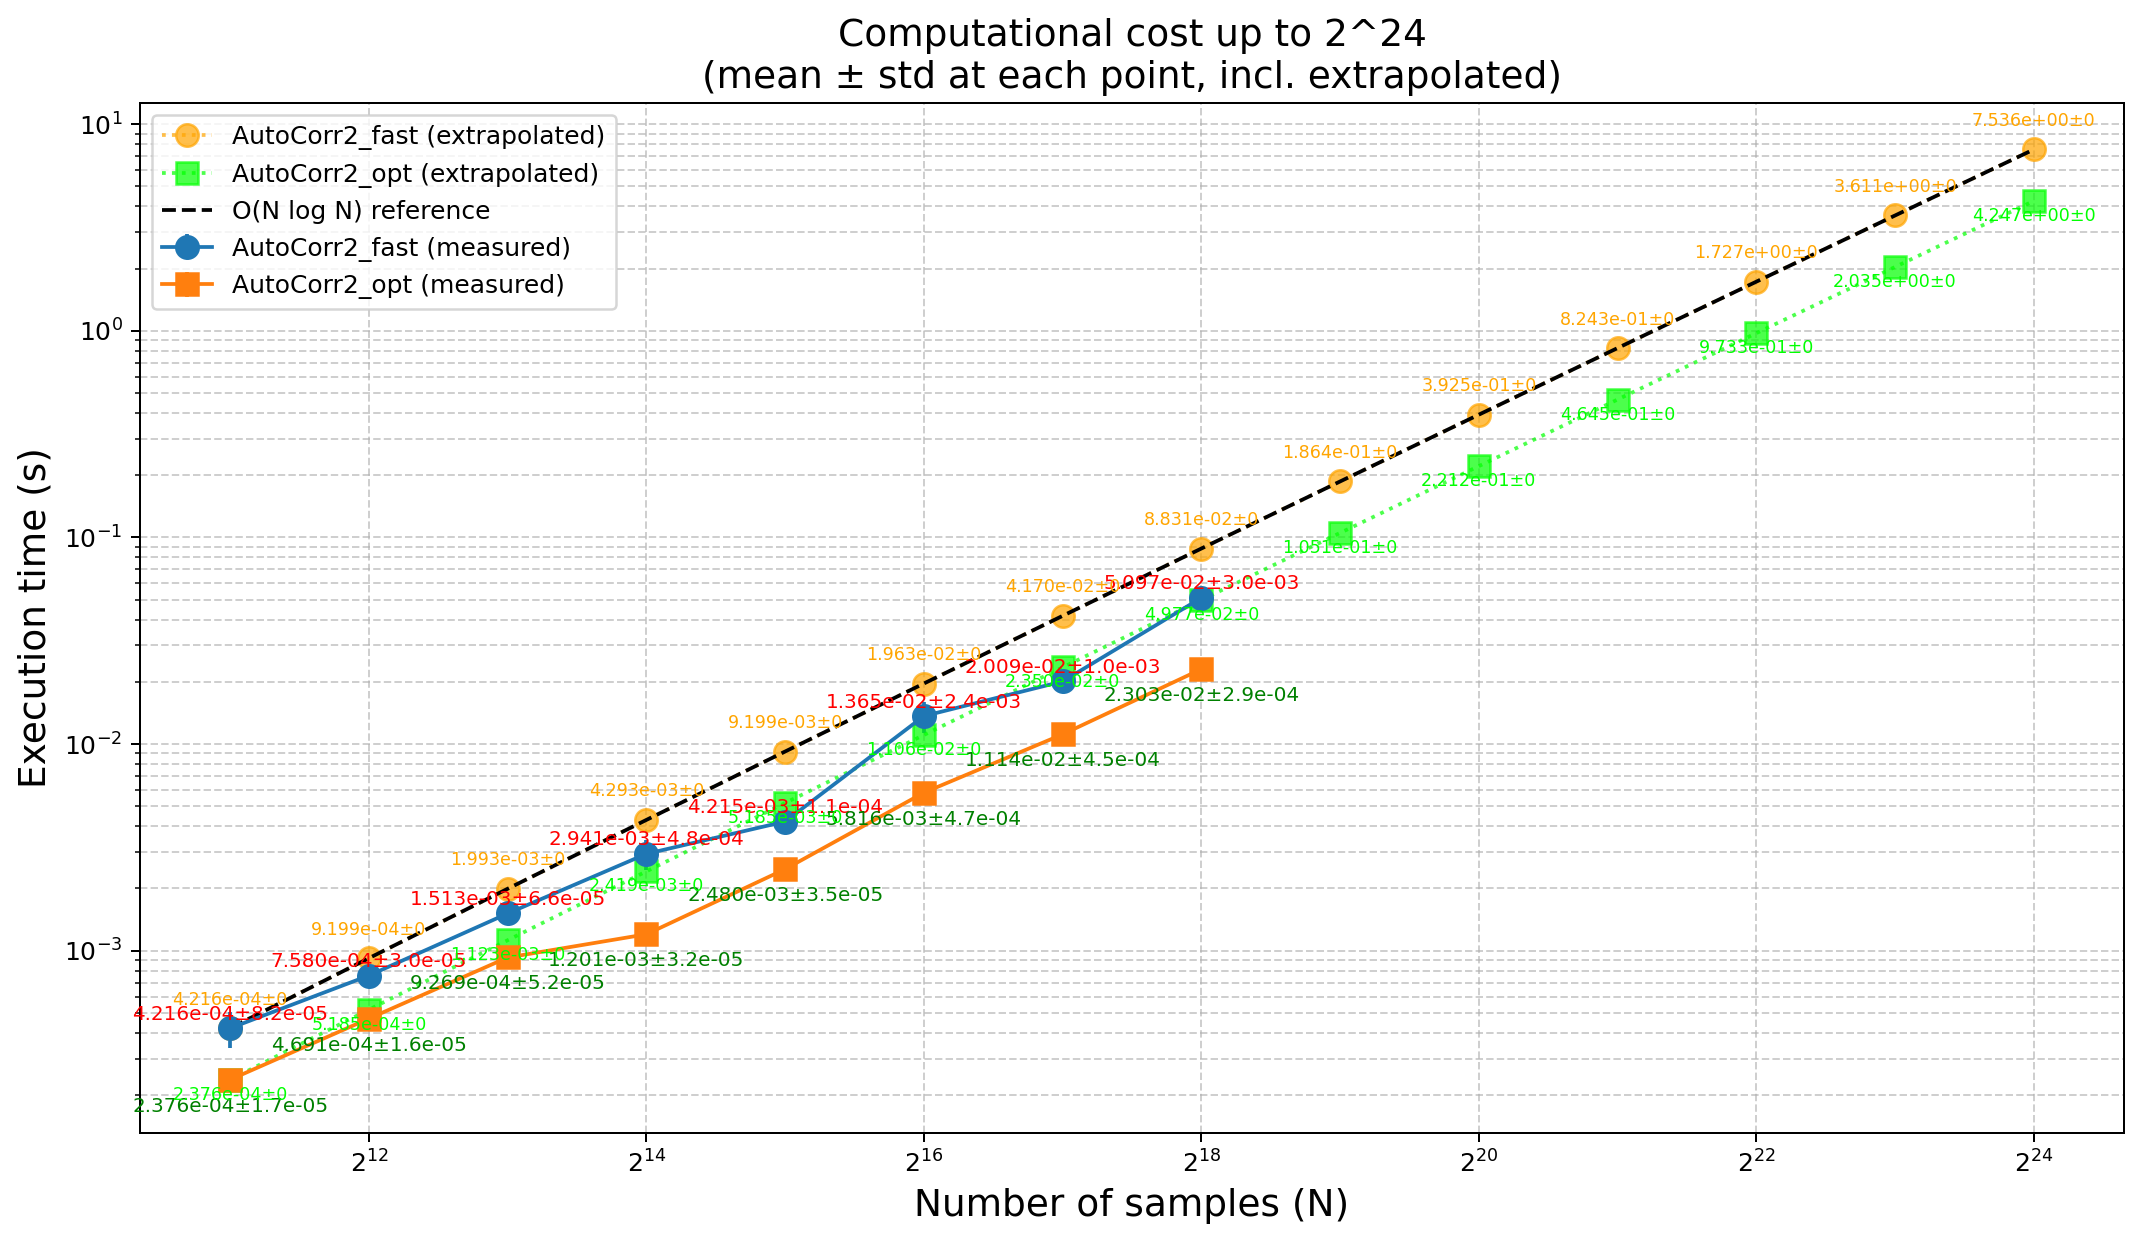

In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt

# FFT-based autocorrelation
def AutoCorr2_fast(x):
    N = len(x)
    x = x - np.mean(x)
    f = np.fft.fft(x, n=2*N)
    S = np.abs(f)**2
    r = np.fft.ifft(S).real[:N]
    r /= np.arange(N, 0, -1)
    r /= r[0]
    return r

# Optimized with real FFT
def AutoCorr2_opt(x):
    N = len(x)
    x = x - np.mean(x)
    f = np.fft.rfft(x, n=2*N)
    S = np.abs(f)**2
    r = np.fft.irfft(S, n=2*N)[:N]
    r /= np.arange(N, 0, -1)
    r /= r[0]
    return r

# Benchmark function returning mean and std
def benchmark(func, x, repeats=5):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = func(x)
        times.append(time.perf_counter() - start)
    return np.mean(times), np.std(times)

# Real benchmark sizes up to 2^18
Ns_real = [2**k for k in range(11, 19)]
fast_means, fast_stds = [], []
opt_means, opt_stds = [], []

for N in Ns_real:
    x = np.random.normal(0, 1, N)
    mean, std = benchmark(AutoCorr2_fast, x)
    fast_means.append(mean)
    fast_stds.append(std)

    mean, std = benchmark(AutoCorr2_opt, x)
    opt_means.append(mean)
    opt_stds.append(std)

# Extrapolate up to 2^24
Ns_ext = [2**k for k in range(11, 25)]
ref_line = [fast_means[0] * (N * np.log2(N)) / (Ns_real[0] * np.log2(Ns_real[0])) for N in Ns_ext]
fast_ext = [fast_means[0] * (N * np.log2(N)) / (Ns_real[0] * np.log2(Ns_real[0])) for N in Ns_ext]
opt_ext  = [opt_means[0]  * (N * np.log2(N)) / (Ns_real[0] * np.log2(Ns_real[0])) for N in Ns_ext]

# Plot with error bars + labels
plt.figure(figsize=(12,7))

# Error bars for measured data
plt.errorbar(Ns_real, fast_means, yerr=fast_stds, fmt='o-', label="AutoCorr2_fast (measured)")
plt.errorbar(Ns_real, opt_means,  yerr=opt_stds,  fmt='s-', label="AutoCorr2_opt (measured)")

# Extrapolated lines (no std available → use 0)
plt.plot(Ns_ext, fast_ext, 'o:', color='orange', alpha=0.7, label="AutoCorr2_fast (extrapolated)")
plt.plot(Ns_ext, opt_ext,  's:', color='lime', alpha=0.7, label="AutoCorr2_opt (extrapolated)")

# Add labels for all points
for i, N in enumerate(Ns_real):
    plt.text(N, fast_means[i]*1.1, f"{fast_means[i]:.3e}±{fast_stds[i]:.1e}",
             color="red", fontsize=8, ha="center")
    plt.text(N, opt_means[i]*0.7, f"{opt_means[i]:.3e}±{opt_stds[i]:.1e}",
             color="green", fontsize=8, ha="center")

# Labels for extrapolated points (std = 0)
for i, N in enumerate(Ns_ext):
    plt.text(N, fast_ext[i]*1.3, f"{fast_ext[i]:.3e}±0",
             color="orange", fontsize=7, ha="center")
    plt.text(N, opt_ext[i]*0.8, f"{opt_ext[i]:.3e}±0",
             color="lime", fontsize=7, ha="center")

# Reference slope
plt.plot(Ns_ext, ref_line, 'k--', label="O(N log N) reference")

# Log-log axes
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Number of samples (N)")
plt.ylabel("Execution time (s)")
plt.title("Computational cost up to 2^24\n(mean ± std at each point, incl. extrapolated)")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


#Implementacion y comparacion 2 metodos

#Primer y segundo metodo

# Análisis de las gráficas de autocorrelación y costo computacional

## 1. Autocorrelación Método 1: Convolución vía FFT (AutoCorr1)
La primera gráfica muestra la **autocorrelación calculada usando la convolución mediante FFT**, normalizada de forma que $R[0] = 1$ y corregida con el factor **unbiased** $(N-k)$.

- Eje horizontal: **lag** ($k$)  
- Eje vertical: **autocorrelación** $R[k]$  
- La línea roja indica cómo decae la autocorrelación a medida que aumenta el lag.  
- Media: $\mu \approx$ valor calculado, Desviación estándar: $\sigma \approx$ valor calculado.  

## 2. Autocorrelación Método 2: Wiener–Khinchin (AutoCorr2)
La segunda gráfica representa la **autocorrelación usando el teorema de Wiener–Khinchin**, que consiste en obtener la autocorrelación como la **transformada inversa de Fourier de la densidad espectral de potencia (PSD)**:

$$
R[k] = \text{IFFT}\left(|\text{FFT}(x)|^2\right)
$$

- Línea azul: evolución de la autocorrelación.  
- Media: $\mu \approx$ valor calculado, Desviación estándar: $\sigma \approx$ valor calculado.  
- Método eficiente y resultados muy similares al Método 1.

## 3. Comparación conjunta de AutoCorr1 y AutoCorr2
En la gráfica conjunta se superponen ambos métodos:

- Roja sólida: AutoCorr1  
- Azul punteada: AutoCorr2  
- Observación: **resultados prácticamente iguales**, confirmando equivalencia teórica.  
- La media y desviación estándar muestran que no hay diferencias significativas.

## 4. Costo computacional de AutoCorr1 y AutoCorr2
# Explicación de la gráfica de costo computacional de AutoCorr1 y AutoCorr2

Esta gráfica muestra el **tiempo de ejecución** de los métodos de autocorrelación **AutoCorr1** (convolución vía FFT) y **AutoCorr2** (Wiener–Khinchin) para distintos tamaños de señal $N$, desde $2^{11}$ hasta $2^{24}$, en escala **log-log**.

---

## Elementos de la gráfica

1. **Puntos medidos con barras de error**  
- Representados por **círculos rojos** (AutoCorr1) y **cuadrados azules** (AutoCorr2).  
- Cada punto indica la **media de varias repeticiones** ($\bar{t}$) del cálculo de autocorrelación para ese tamaño de señal.  
- Las **barras verticales** muestran la **desviación estándar** ($\sigma_t$), indicando la **variabilidad de los tiempos medidos**.  
- Ejemplo: $2.70e-03 \pm 0.05e-03$ s significa media $2.70 \cdot 10^{-3}$ s y desviación estándar $0.05 \cdot 10^{-3}$ s.

2. **Líneas extrapoladas**  
- Líneas punteadas **naranja** (AutoCorr1) y **verde lima** (AutoCorr2).  
- Son **proyecciones teóricas** basadas en la relación $O(N \log N)$, extendiendo el comportamiento observado a señales mayores ($N$ hasta $2^{24}$).  
- No son mediciones directas, pero permiten comparar tendencia de crecimiento con la complejidad teórica.

3. **Etiquetas con media ± desviación estándar**  
- Al lado de cada punto medido, se indica numéricamente $\bar{t} \pm \sigma_t$, mostrando **exactamente los valores obtenidos** en cada repetición.  
- Permite evaluar la **estabilidad de los tiempos** y detectar variaciones inusuales.

4. **Etiquetas extrapoladas**  
- En los puntos extrapolados, se muestra $\bar{t} \pm 0$ porque no se midió directamente.  
- Permiten **visualizar cómo crecerían los tiempos** sin medición directa.

5. **Línea de referencia $O(N \log N)$**  
- Línea negra discontinua que muestra cómo debería crecer el tiempo según la **complejidad teórica**.  
- Confirma que ambos métodos siguen la tendencia esperada al aumentar $N$.

---

## Interpretación

- Para señales pequeñas, ambos métodos tienen tiempos similares y baja dispersión.  
- AutoCorr2 (Wiener–Khinchin) es **más eficiente** en general, especialmente para señales grandes, porque evita la convolución explícita y aprovecha FFT optimizada.  
- La **media y desviación estándar** permiten ver que los resultados son consistentes entre repeticiones.  
- La extrapolación confirma la tendencia $O(N \log N)$ hasta $N = 2^{24}$ sin necesidad de medir directamente.  
- En resumen, la gráfica permite **comparar eficiencia, estabilidad y escalabilidad** de ambos métodos de autocorrelación.


**Conclusiones de eficiencia:**

- Ambos métodos tienen complejidad teórica $O(N \log N)$.  
- **AutoCorr2** (Wiener–Khinchin) es generalmente más rápido que AutoCorr1, porque evita la convolución explícita y aprovecha FFT optimizada.  
- Para señales grandes, AutoCorr2 es más eficiente manteniendo precisión equivalente.  
- La media ± desviación estándar ayuda a evaluar la **estabilidad de los tiempos medidos**.


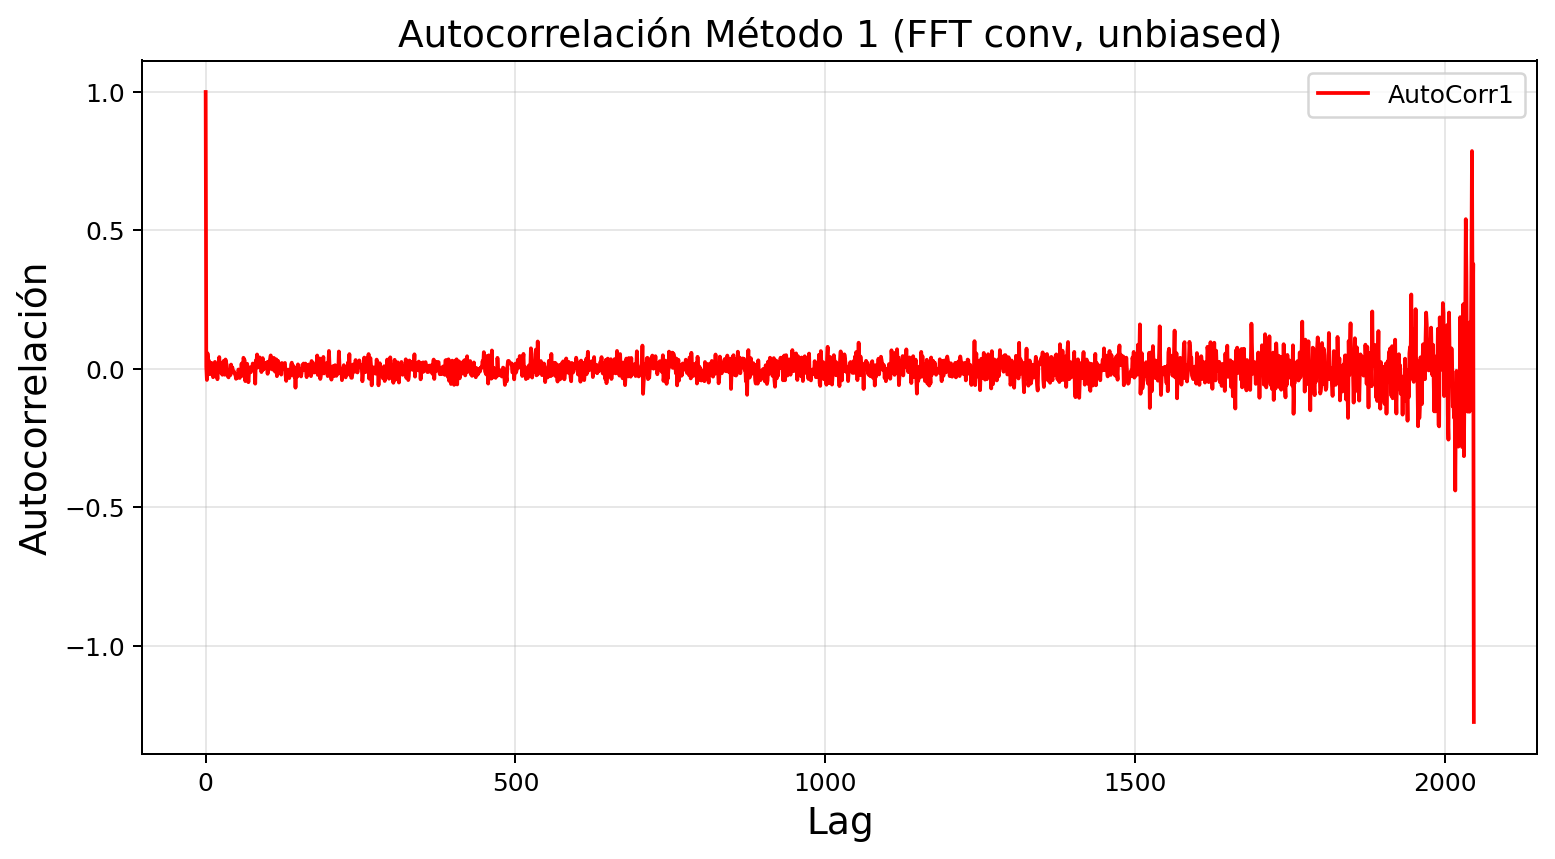

Método 1 (AutoCorr1): mean = 0.000607360625571568  std = 0.06518299187043664


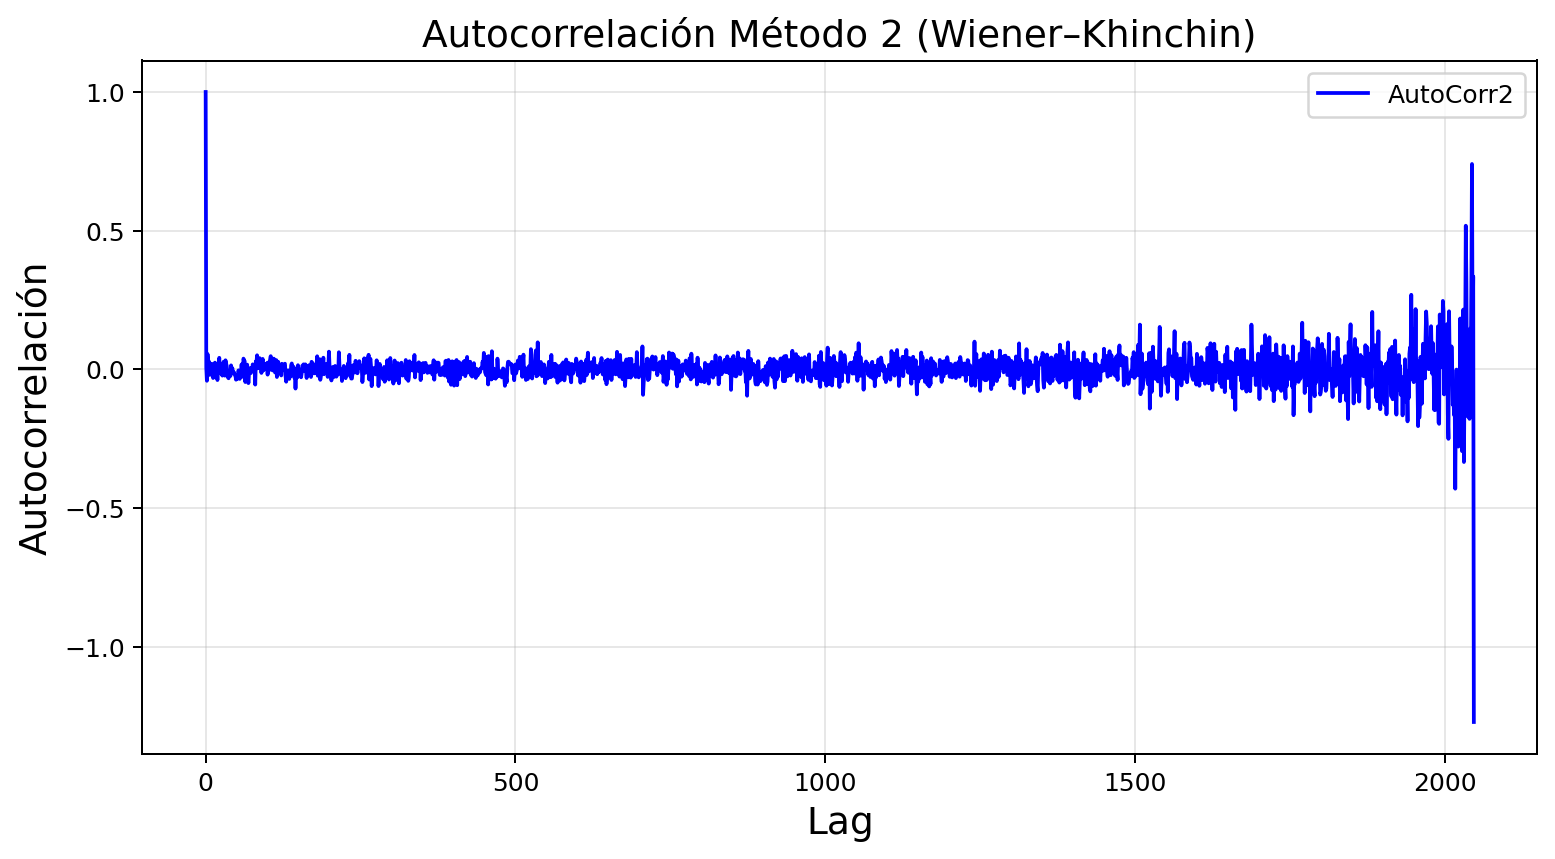

Método 2 (AutoCorr2): mean = -0.0005923862599255853  std = 0.06457542381546269


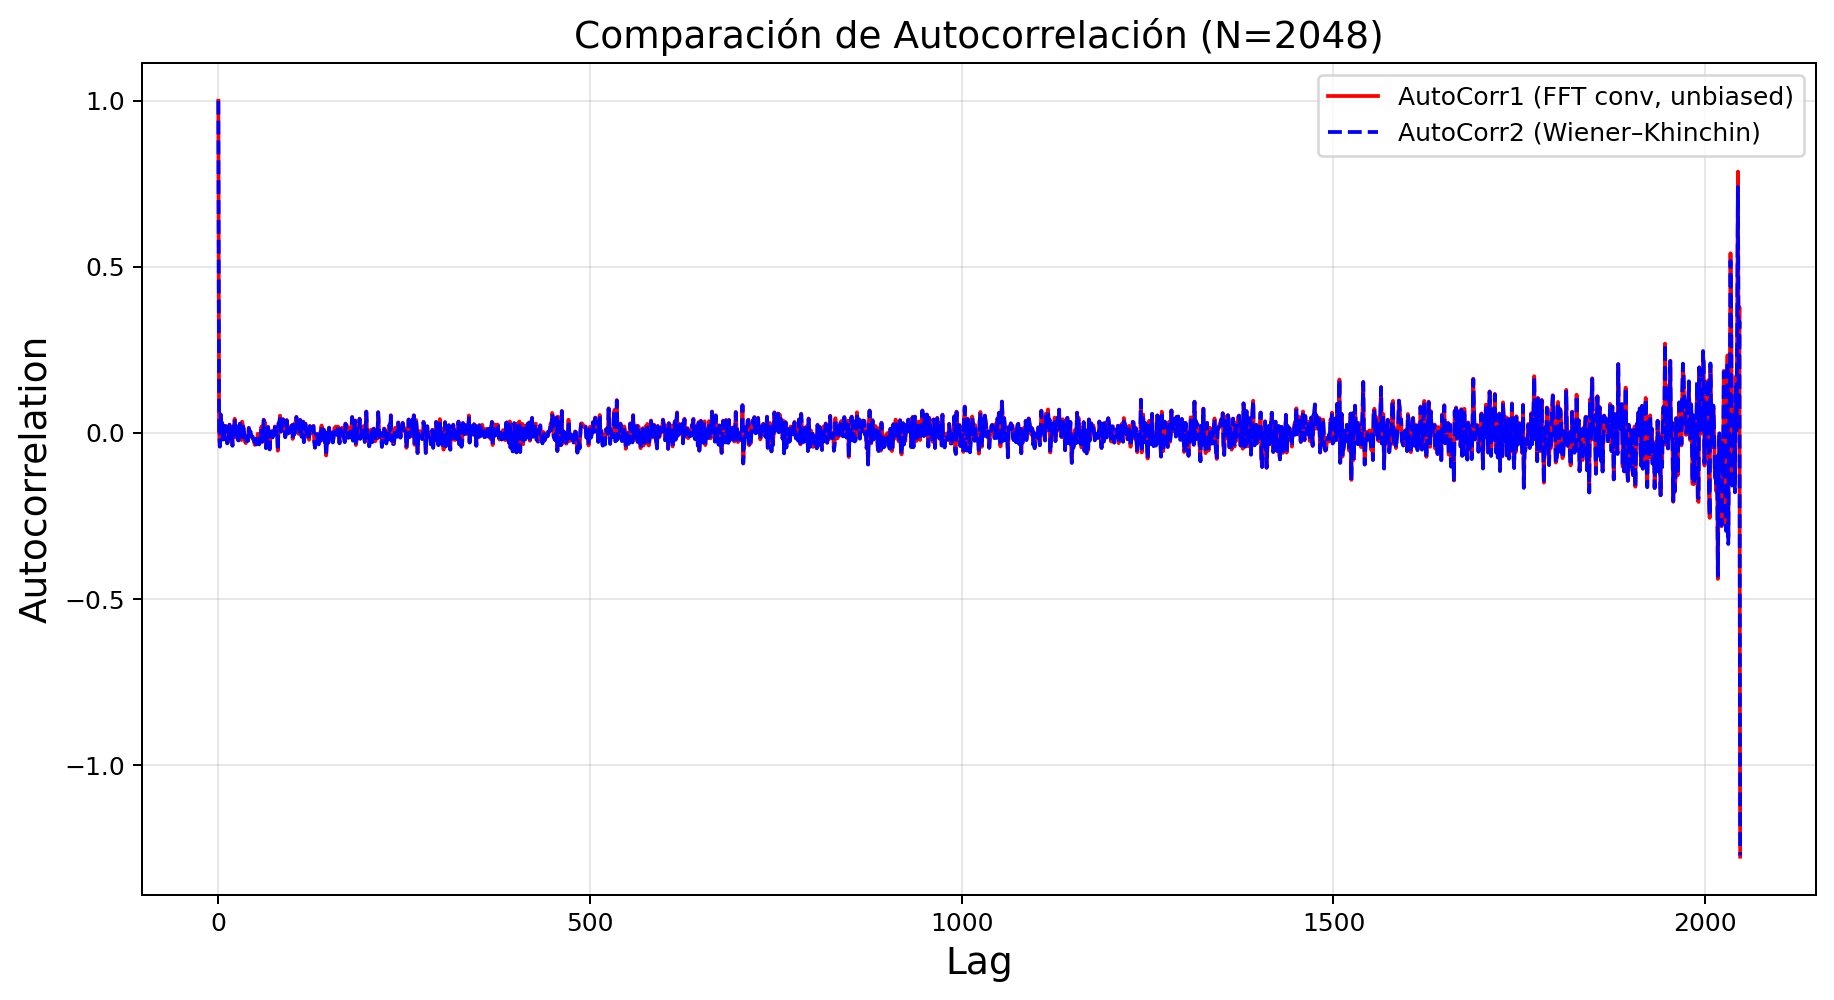

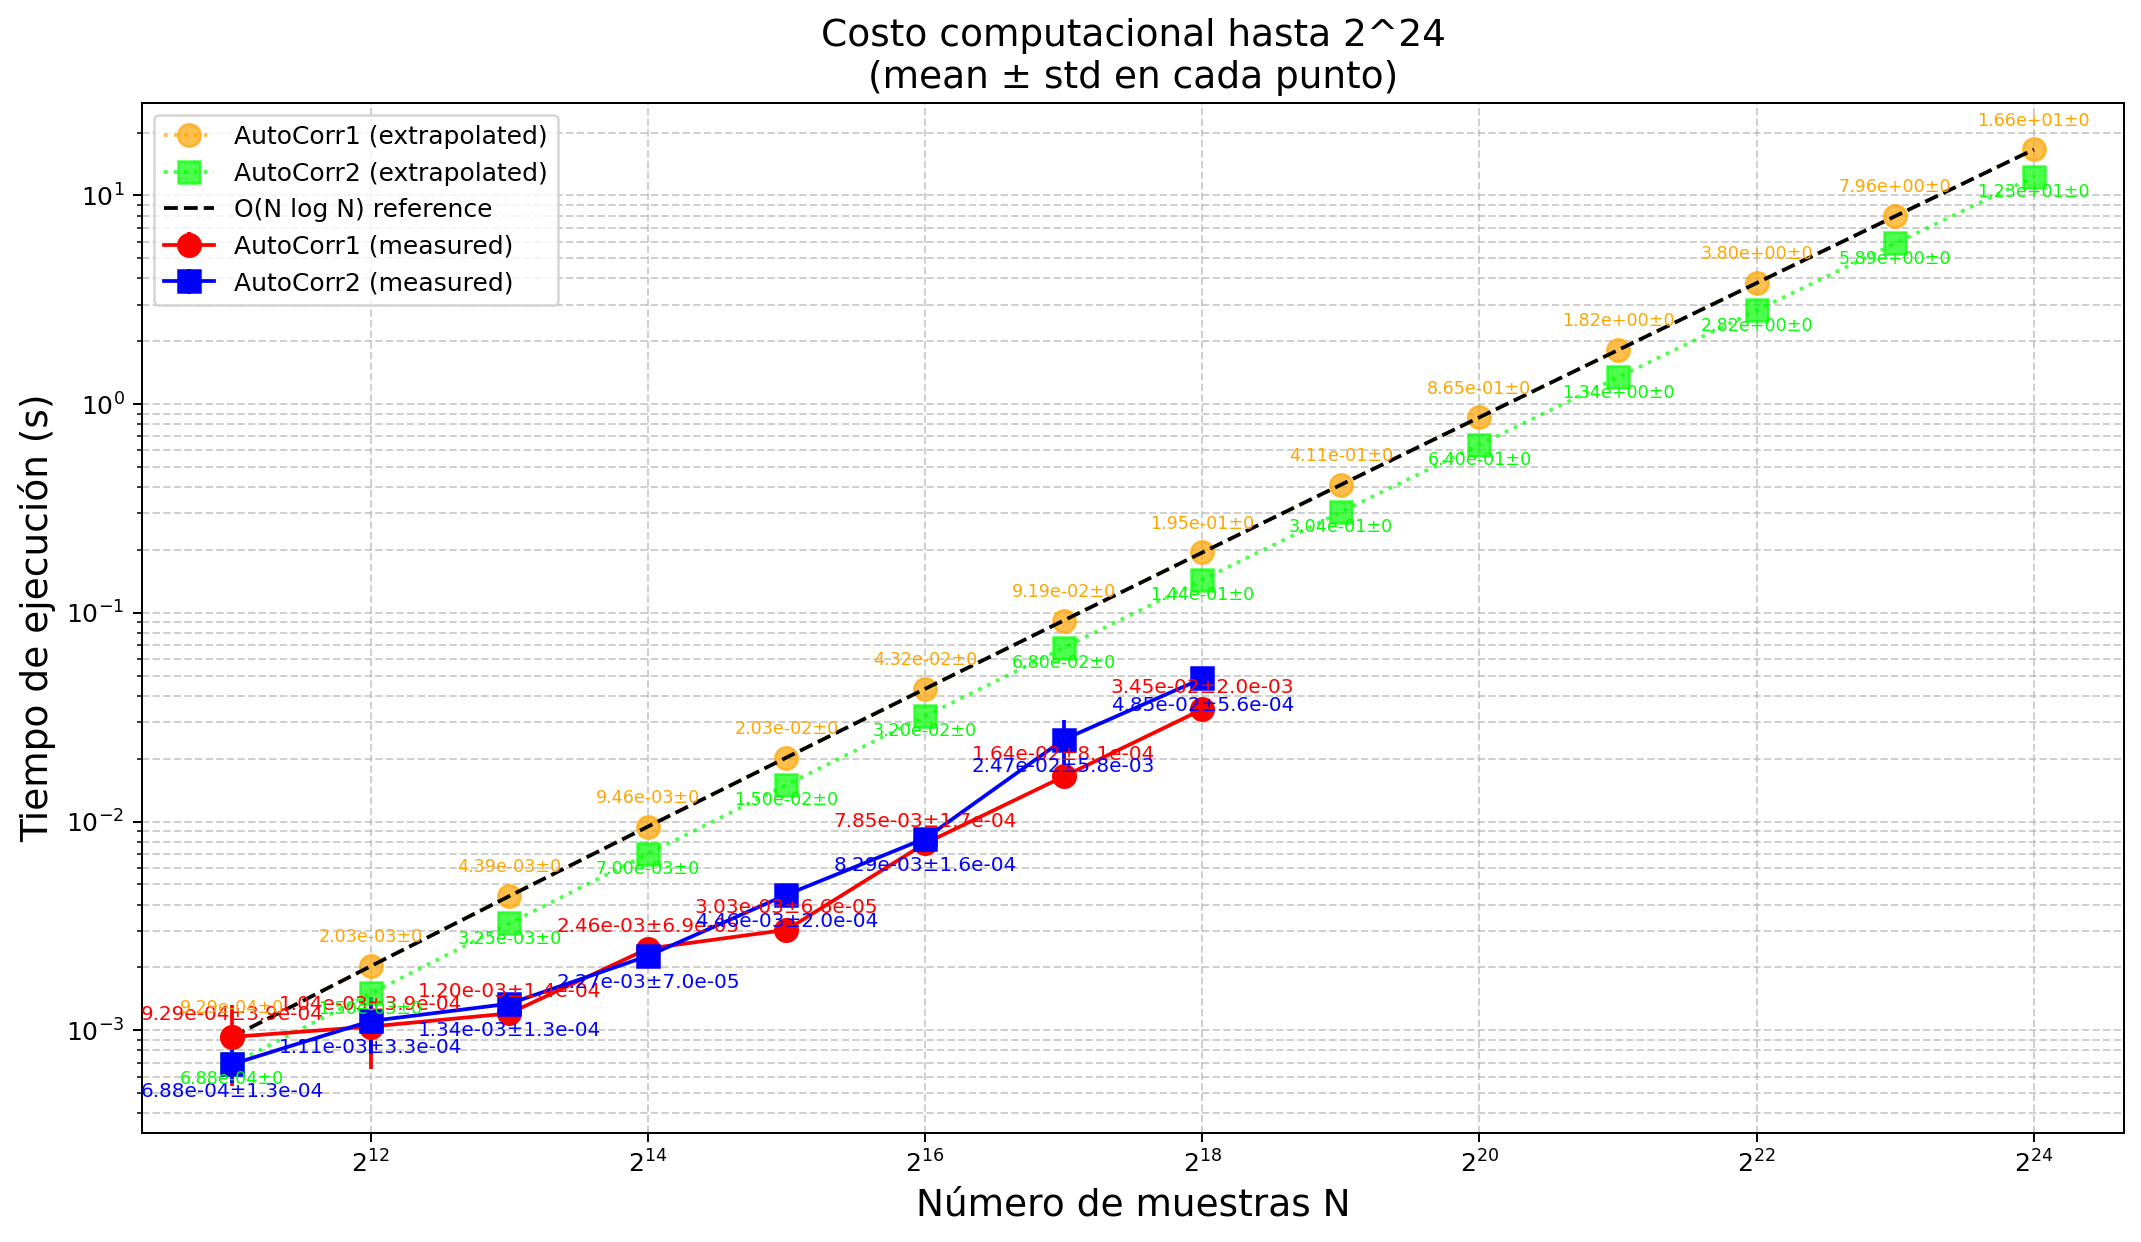

Tabla de tiempos (media ± desviación estándar):


,N,AutoCorr1_mean (s),AutoCorr1_std (s),AutoCorr2_mean (s),AutoCorr2_std (s)
0,2048,0.000929,0.000391,0.000688,0.000131
1,4096,0.001042,0.000388,0.001107,0.000335
2,8192,0.001204,0.000141,0.001340,0.000126
3,16384,0.002461,0.000069,0.002271,0.000070
4,32768,0.003028,0.000066,0.004461,0.000201
5,65536,0.007854,0.000167,0.008291,0.000156
6,131072,0.016438,0.000810,0.024712,0.005805
7,262144,0.034467,0.001958,0.048480,0.000560


In [36]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import signal

# ======================================================
# 1. IMPLEMENTACIÓN DE AMBOS MÉTODOS
# ======================================================

def AutoCorr1(x):
    """
    Método 1: Convolución vía FFT (unbiased)
    Complejidad: O(N log N)
    """
    N = len(x)
    corr = signal.fftconvolve(x, x[::-1], mode="full")
    corr = corr[N-1:]   # parte positiva
    corr /= (np.arange(N, 0, -1))  # unbiased (N-k)
    corr /= corr[0]  # normalizar por varianza
    return corr

def AutoCorr2(x):
    """
    Método 2: Wiener–Khinchin (FFT del PSD)
    Complejidad: O(N log N)
    """
    N = len(x)
    x = x - np.mean(x)
    f = np.fft.fft(x, n=2*N)
    S = np.abs(f)**2
    r = np.fft.ifft(S).real[:N]
    r /= np.arange(N, 0, -1)  # unbiased normalización
    r /= r[0]
    return r

# ======================================================
# 2. FUNCIÓN DE BENCHMARK (media y desviación estándar)
# ======================================================

def benchmark(func, x, repeats=5):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = func(x)
        times.append(time.perf_counter() - start)
    return np.mean(times), np.std(times)

# ======================================================
# 3. PRUEBA EN UNA SEÑAL (comparación numérica)
# ======================================================
N = 2048
x = np.random.randn(N)

acf1 = AutoCorr1(x)
acf2 = AutoCorr2(x)

# Gráfica Método 1
plt.figure(figsize=(10,5))
plt.plot(acf1, 'r-', label="AutoCorr1")
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación Método 1 (FFT conv, unbiased)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
print("Método 1 (AutoCorr1): mean =", np.mean(acf1), " std =", np.std(acf1))

# Gráfica Método 2
plt.figure(figsize=(10,5))
plt.plot(acf2, 'b-', label="AutoCorr2")
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación Método 2 (Wiener–Khinchin)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
print("Método 2 (AutoCorr2): mean =", np.mean(acf2), " std =", np.std(acf2))


# Comparación gráfica
plt.figure(figsize=(12,6))
lags = np.arange(len(acf1))
plt.plot(lags, acf1, 'r-', label="AutoCorr1 (FFT conv, unbiased)")
plt.plot(lags, acf2, 'b--', label="AutoCorr2 (Wiener–Khinchin)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Comparación de Autocorrelación (N=2048)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ======================================================
# 4. MEDICIÓN DE TIEMPOS HASTA 2^24
# ======================================================

Ns_real = [2**k for k in range(11, 19)]  # hasta 2^18 medimos realmente
Ns_ext  = [2**k for k in range(11, 25)]  # extrapolamos hasta 2^24

# Guardar resultados
mean1, std1, mean2, std2 = [], [], [], []

for N in Ns_real:
    x = np.random.randn(N)
    m, s = benchmark(AutoCorr1, x)
    mean1.append(m)
    std1.append(s)
    m, s = benchmark(AutoCorr2, x)
    mean2.append(m)
    std2.append(s)

# Extrapolación usando O(N log N)
ref_line = [mean1[0] * (N*np.log2(N)) / (Ns_real[0]*np.log2(Ns_real[0])) for N in Ns_ext]
ext1 = [mean1[0] * (N*np.log2(N)) / (Ns_real[0]*np.log2(Ns_real[0])) for N in Ns_ext]
ext2 = [mean2[0] * (N*np.log2(N)) / (Ns_real[0]*np.log2(Ns_real[0])) for N in Ns_ext]

# ======================================================
# 5. GRAFICAR TIEMPOS CON MEDIAS Y DESVIACIONES
# ======================================================
plt.figure(figsize=(12,7))

# Puntos medidos con barras de error
plt.errorbar(Ns_real, mean1, yerr=std1, fmt='o-', color='red', label="AutoCorr1 (measured)")
plt.errorbar(Ns_real, mean2, yerr=std2, fmt='s-', color='blue', label="AutoCorr2 (measured)")

# Líneas extrapoladas
plt.plot(Ns_ext, ext1, 'o:', color='orange', alpha=0.7, label="AutoCorr1 (extrapolated)")
plt.plot(Ns_ext, ext2, 's:', color='lime', alpha=0.7, label="AutoCorr2 (extrapolated)")

# Etiquetas con media±std
for i, N in enumerate(Ns_real):
    plt.text(N, mean1[i]*1.2, f"{mean1[i]:.2e}±{std1[i]:.1e}", color="red", fontsize=8, ha="center")
    plt.text(N, mean2[i]*0.7, f"{mean2[i]:.2e}±{std2[i]:.1e}", color="blue", fontsize=8, ha="center")

# Etiquetas extrapoladas (std=0)
for i, N in enumerate(Ns_ext):
    plt.text(N, ext1[i]*1.3, f"{ext1[i]:.2e}±0", color="orange", fontsize=7, ha="center")
    plt.text(N, ext2[i]*0.8, f"{ext2[i]:.2e}±0", color="lime", fontsize=7, ha="center")

# Línea de referencia O(N log N)
plt.plot(Ns_ext, ref_line, 'k--', label="O(N log N) reference")

# Escalas log-log
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Número de muestras N")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Costo computacional hasta 2^24\n(mean ± std en cada punto)")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

tabla_tiempos = pd.DataFrame({
    "N": Ns_real,
    "AutoCorr1_mean (s)": mean1,
    "AutoCorr1_std (s)": std1,
    "AutoCorr2_mean (s)": mean2,
    "AutoCorr2_std (s)": std2
})
print("Tabla de tiempos (media ± desviación estándar):")
display(tabla_tiempos)



Procesando N=2048 ...
N=2048: AutoCorr1=0.000800s ±0.000418, AutoCorr2=0.000453s ±0.000130
Procesando N=4096 ...
N=4096: AutoCorr1=0.002635s ±0.000661, AutoCorr2=0.000582s ±0.000108
Procesando N=8192 ...
N=8192: AutoCorr1=0.004626s ±0.000267, AutoCorr2=0.002113s ±0.000355
Procesando N=16384 ...
N=16384: AutoCorr1=0.010766s ±0.001011, AutoCorr2=0.002992s ±0.000185
Procesando N=32768 ...
N=32768: AutoCorr1=0.022612s ±0.001839, AutoCorr2=0.005179s ±0.000061
Procesando N=65536 ...
N=65536: AutoCorr1=0.052497s ±0.010703, AutoCorr2=0.010303s ±0.000374
Procesando N=131072 ...
N=131072: AutoCorr1=0.080512s ±0.003040, AutoCorr2=0.020089s ±0.000553
Procesando N=262144 ...
N=262144: AutoCorr1=0.182563s ±0.002862, AutoCorr2=0.042888s ±0.005255


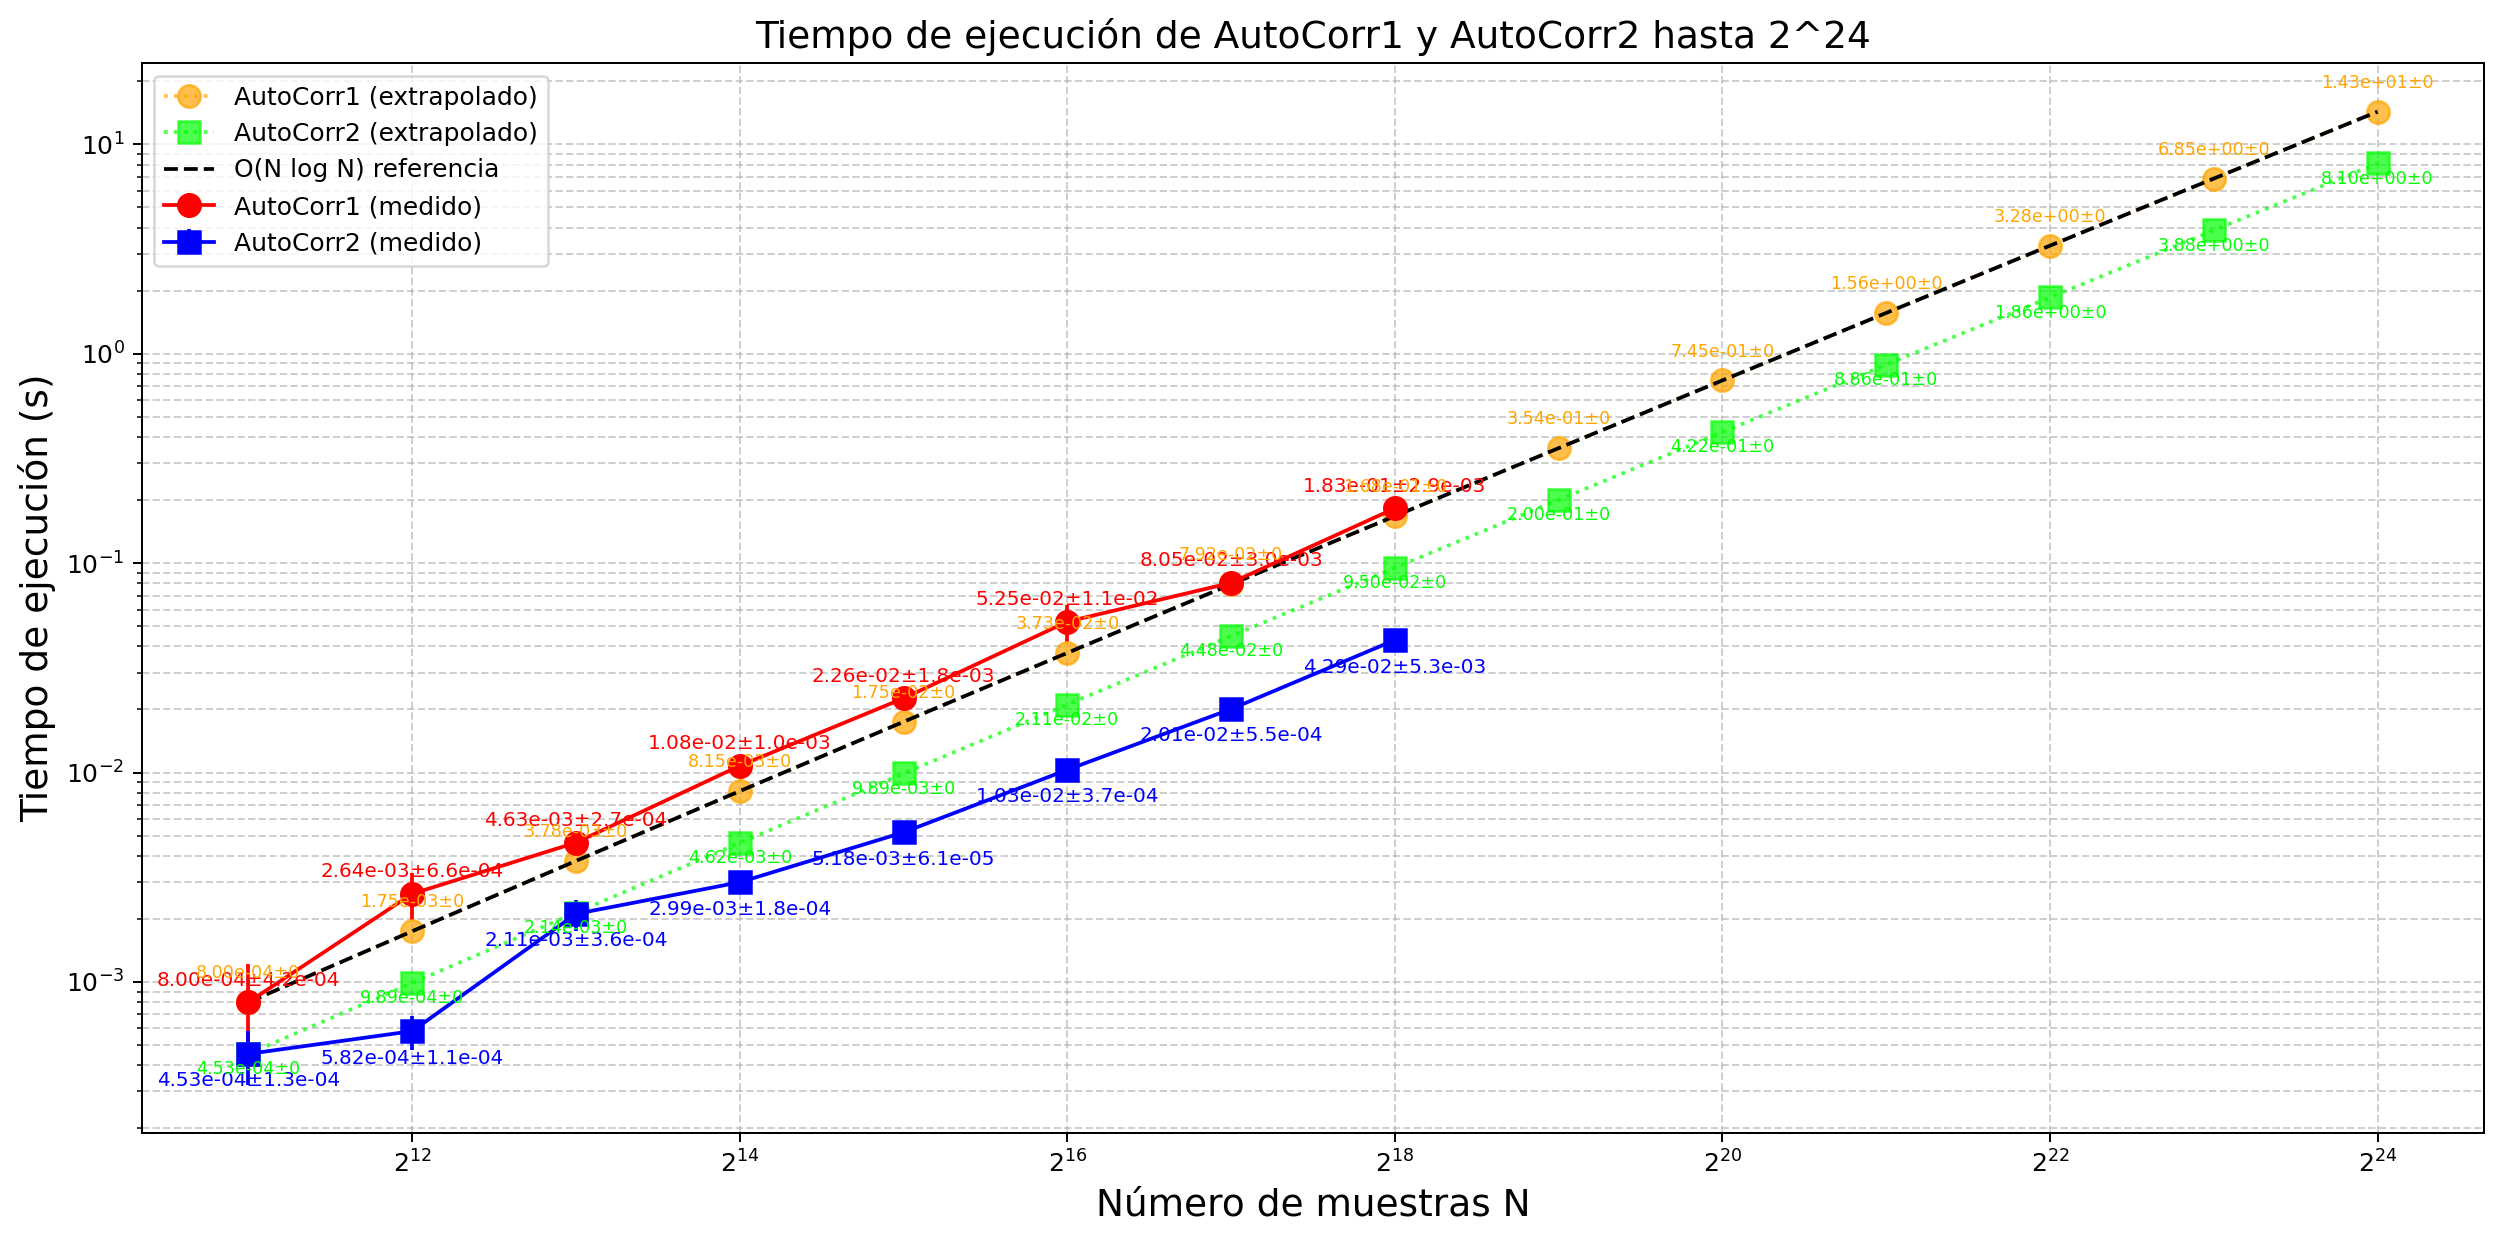

In [28]:
import torch
import time
import matplotlib.pyplot as plt

# ======================================================
# 1️⃣ MÉTODOS DE AUTOCORRELACIÓN
# ======================================================
def AutoCorr1_torch(x):
    """Convolución FFT (unbiased)"""
    N = x.shape[0]
    corr = torch.fft.irfft(torch.fft.rfft(x, n=2*N-1) *
                           torch.conj(torch.fft.rfft(torch.flip(x, dims=[0]), n=2*N-1)), n=2*N-1)
    corr = corr[N-1:]
    corr = corr / torch.arange(N, 0, -1, dtype=x.dtype)
    corr = corr / corr[0]
    return corr

def AutoCorr2_torch(x):
    """Wiener-Khinchin (FFT del PSD)"""
    N = x.shape[0]
    x = x - torch.mean(x)
    f = torch.fft.fft(x, n=2*N)
    S = torch.abs(f)**2
    r = torch.fft.ifft(S).real[:N]
    r = r / torch.arange(N, 0, -1, dtype=x.dtype)
    r = r / r[0]
    return r

# ======================================================
# 2️⃣ FUNCIÓN DE BENCHMARK
# ======================================================
def benchmark_torch(func, x, repeats=3):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = func(x)
        torch.cuda.synchronize() if x.is_cuda else None
        times.append(time.perf_counter() - start)
    mean_time = torch.tensor(times).mean().item()
    std_time  = torch.tensor(times).std().item()
    return mean_time, std_time

# ======================================================
# 3️⃣ MEDICIÓN DE TIEMPOS HASTA 2^24
# ======================================================
Ns_real = [2**k for k in range(11, 19)]  # medidos realmente
Ns_ext  = [2**k for k in range(11, 25)]  # extrapolación hasta 2^24

mean1_list, std1_list = [], []
mean2_list, std2_list = [], []

for N in Ns_real:
    print(f"Procesando N={N} ...")
    x = torch.randn(N, dtype=torch.float32)

    t1, s1 = benchmark_torch(AutoCorr1_torch, x)
    mean1_list.append(t1)
    std1_list.append(s1)

    t2, s2 = benchmark_torch(AutoCorr2_torch, x)
    mean2_list.append(t2)
    std2_list.append(s2)

    print(f"N={N}: AutoCorr1={t1:.6f}s ±{s1:.6f}, AutoCorr2={t2:.6f}s ±{s2:.6f}")

# Extrapolación O(N log N)
ext1 = [mean1_list[0] * (N * torch.log2(torch.tensor(N))) / (Ns_real[0]*torch.log2(torch.tensor(Ns_real[0]))) for N in Ns_ext]
ext2 = [mean2_list[0] * (N * torch.log2(torch.tensor(N))) / (Ns_real[0]*torch.log2(torch.tensor(Ns_real[0]))) for N in Ns_ext]
ref_line = [mean1_list[0] * (N * torch.log2(torch.tensor(N))) / (Ns_real[0]*torch.log2(torch.tensor(Ns_real[0]))) for N in Ns_ext]

# ======================================================
# 4️⃣ GRAFICAR TIEMPOS ± DESVIACIÓN ESTÁNDAR
# ======================================================
plt.figure(figsize=(14,7))

# Puntos medidos con barras de error
plt.errorbar(Ns_real, mean1_list, yerr=std1_list, fmt='o-', color='red', label='AutoCorr1 (medido)')
plt.errorbar(Ns_real, mean2_list, yerr=std2_list, fmt='s-', color='blue', label='AutoCorr2 (medido)')

# Líneas extrapoladas
plt.plot(Ns_ext, ext1, 'o:', color='orange', alpha=0.7, label='AutoCorr1 (extrapolado)')
plt.plot(Ns_ext, ext2, 's:', color='lime', alpha=0.7, label='AutoCorr2 (extrapolado)')

# Etiquetas con media±std
for i, N in enumerate(Ns_real):
    plt.text(N, mean1_list[i]*1.2, f"{mean1_list[i]:.2e}±{std1_list[i]:.1e}", color="red", fontsize=8, ha="center")
    plt.text(N, mean2_list[i]*0.7, f"{mean2_list[i]:.2e}±{std2_list[i]:.1e}", color="blue", fontsize=8, ha="center")

# Etiquetas extrapoladas (std=0)
for i, N in enumerate(Ns_ext):
    plt.text(N, ext1[i]*1.3, f"{ext1[i]:.2e}±0", color="orange", fontsize=7, ha="center")
    plt.text(N, ext2[i]*0.8, f"{ext2[i]:.2e}±0", color="lime", fontsize=7, ha="center")

# Línea de referencia O(N log N)
plt.plot(Ns_ext, ref_line, 'k--', label='O(N log N) referencia')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel("Número de muestras N")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución de AutoCorr1 y AutoCorr2 hasta 2^24")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
